# Using Chart Primitives with pandas data

Primitives are low-level display components that control how data is rendered on the chart. Some primitives act on an indicator. They take the indicator as first parameter, like `LinePlot(SMA(50), color=...)`, or equivalently via the `@` binding operator: `SMA(50) @ LinePlot(color=...)`.


In [18]:
from mplchart.indicators import SMA, RSI, MACD, ROC, ADX
from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.primitives import Candlesticks, OHLC, Price, Volume, LinePlot, AreaPlot, BarPlot, Markers, Stripes, Peaks, ZigZag, Pane, HLine

prices = sample_prices()

## Candlesticks

Japanese candlestick chart. Supports `alpha`, `use_bars`, `colorup`, `colordn` options.

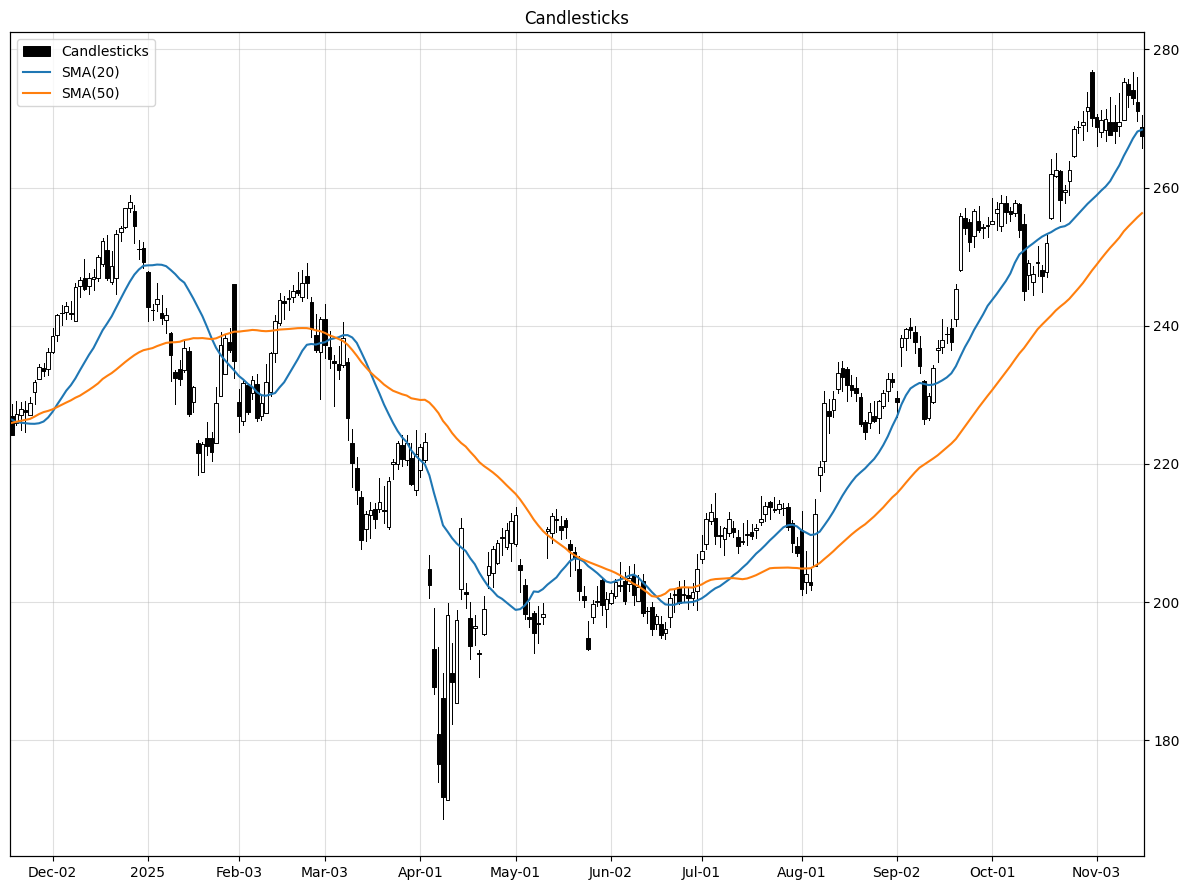

In [19]:
# Candlesticks with moving averages
Chart(prices, title="Candlesticks", max_bars=250).plot(
    Candlesticks(),
    SMA(20),
    SMA(50),
).show()

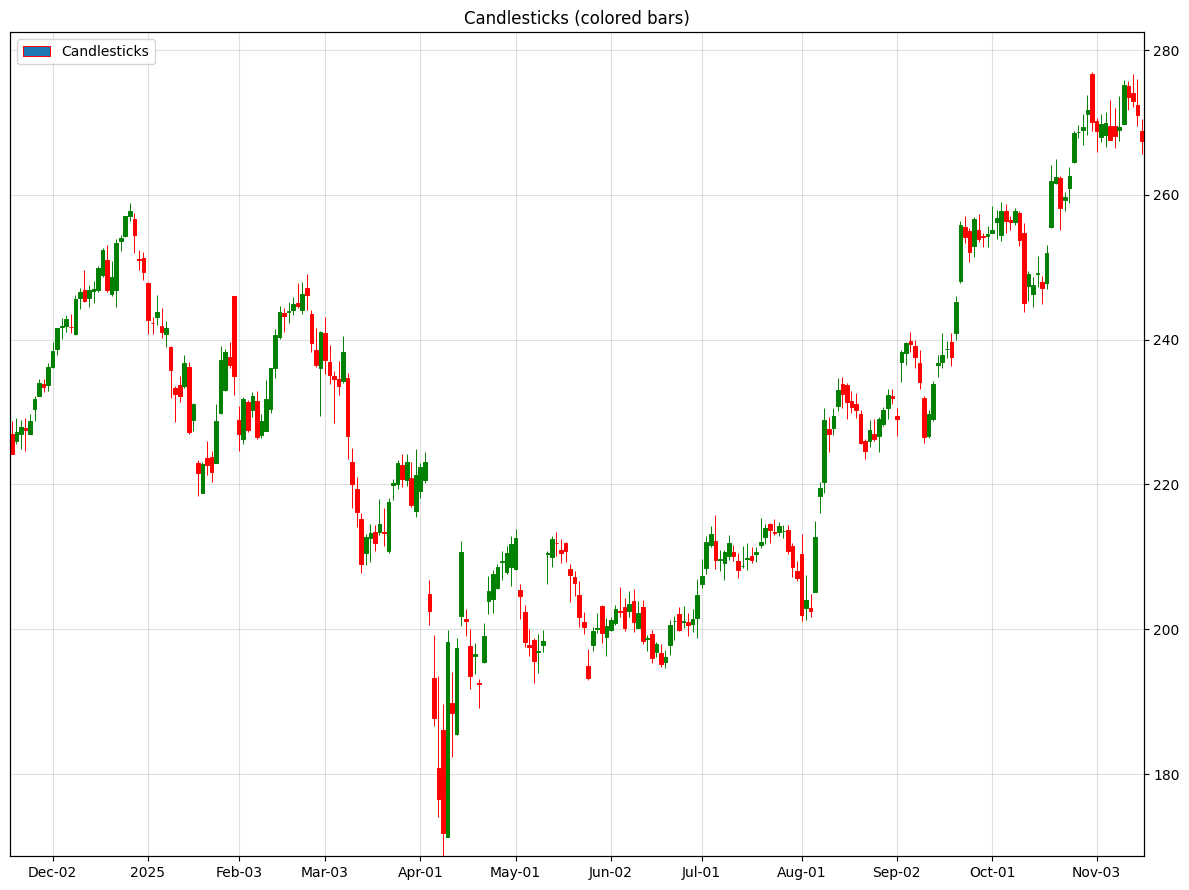

In [20]:
# Candlesticks with colored bars
Chart(prices, title="Candlesticks (colored bars)", max_bars=250).plot(
    Candlesticks(use_bars=True, colorup="green", colordn="red")
).show()

## OHLC

Traditional Open-High-Low-Close bar chart.

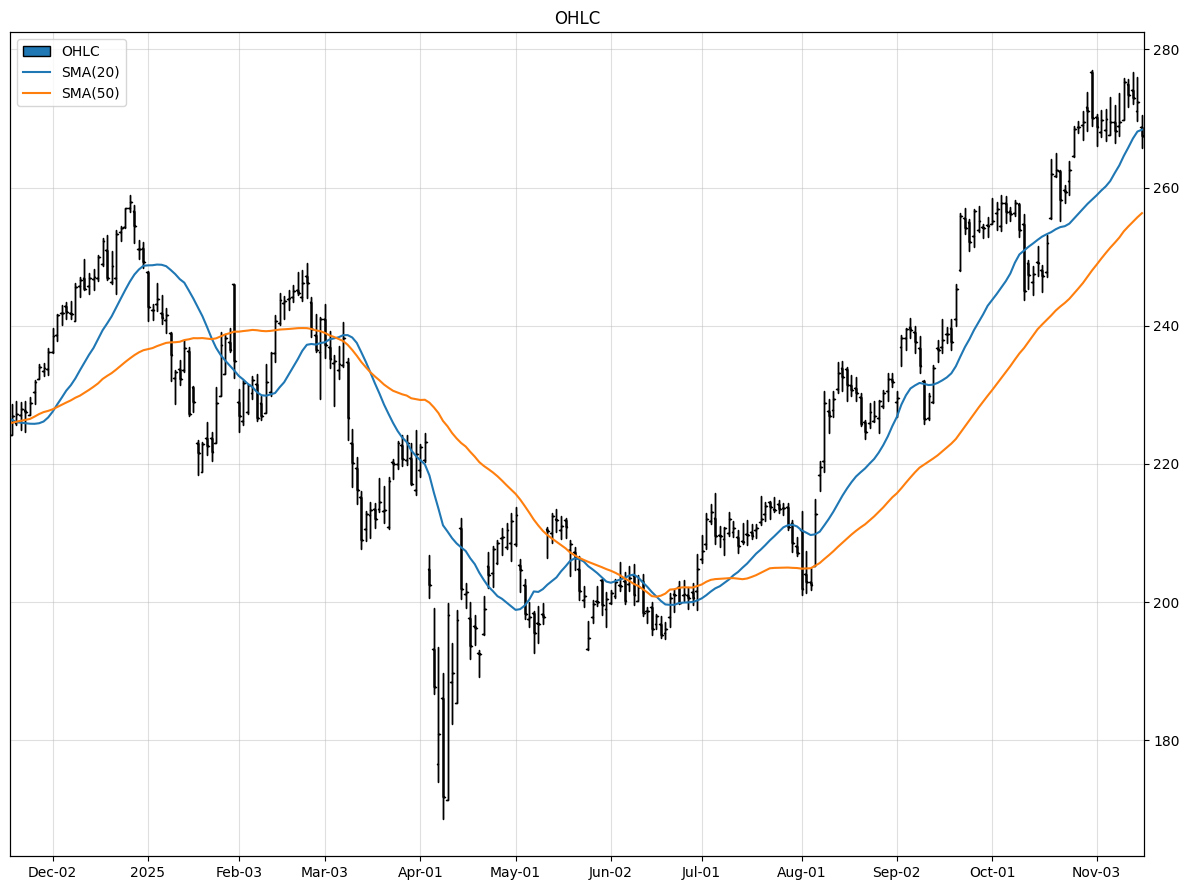

In [21]:
# OHLC with moving averages
Chart(prices, title="OHLC", max_bars=250).plot(
    OHLC(),
    SMA(20),
    SMA(50),
).show()

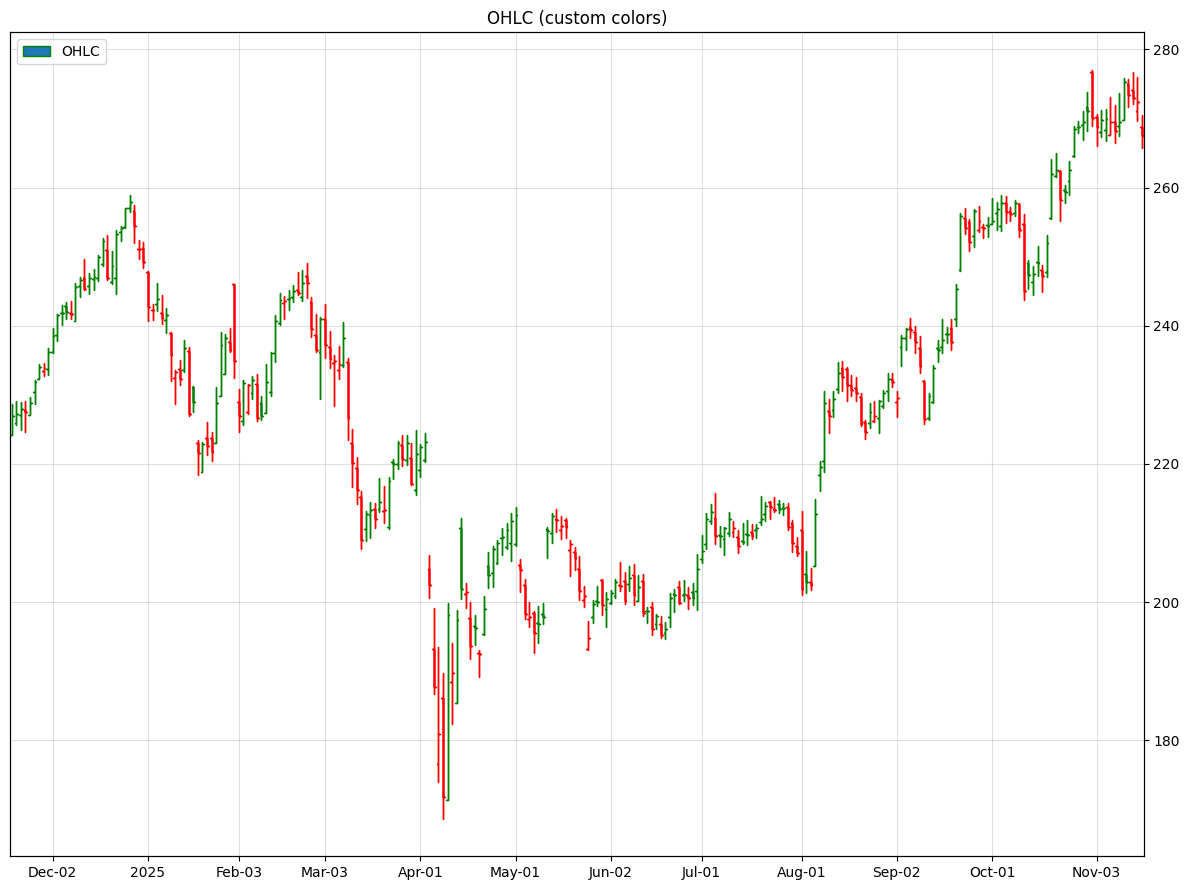

In [22]:
# OHLC with custom colors
Chart(prices, title="OHLC (custom colors)", max_bars=250).plot(
    OHLC(colorup="g", colordn="r")
).show()

## Price

Simple close price line.

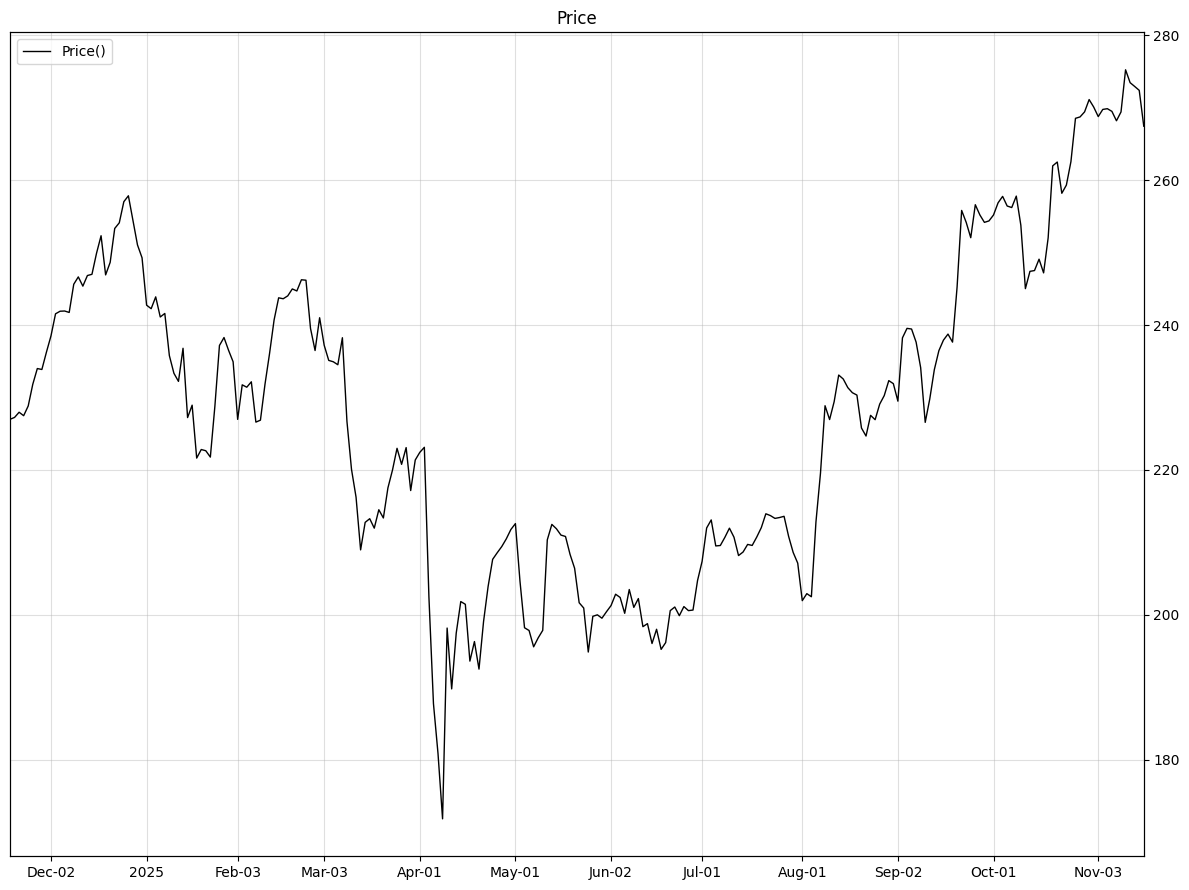

In [23]:
Chart(prices, title="Price", max_bars=250).plot(
    Price()
).show()

## Volume

Volume bars with optional moving average overlay.

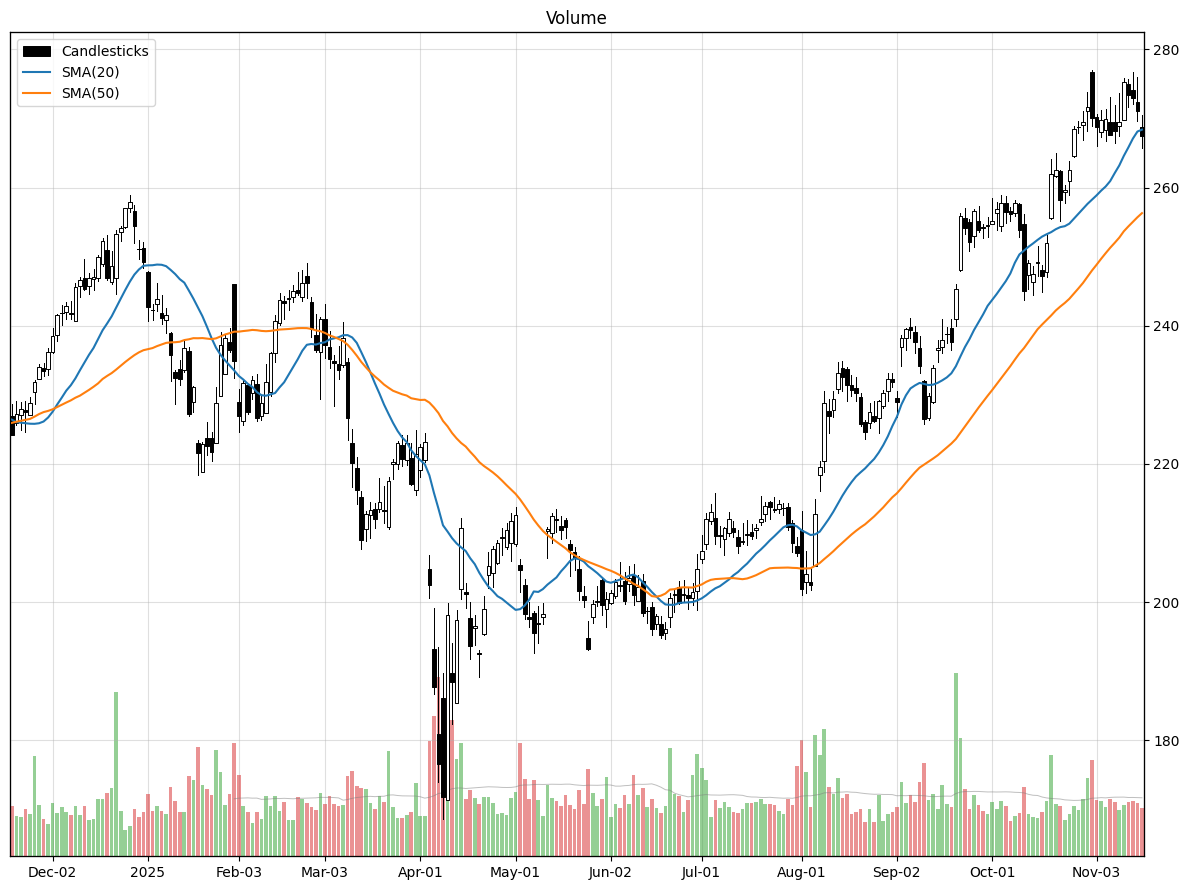

In [24]:
Chart(prices, title="Volume", max_bars=250).plot(
    Candlesticks(),
    Volume(sma=50),
    SMA(20),
    SMA(50),
).show()

## Line

Custom line renderer for indicators. Supports `style` (`solid`, `dashed`, `marker`), `color`, `alpha`, `width`.
Use `|` to pipe an indicator through `Line`.

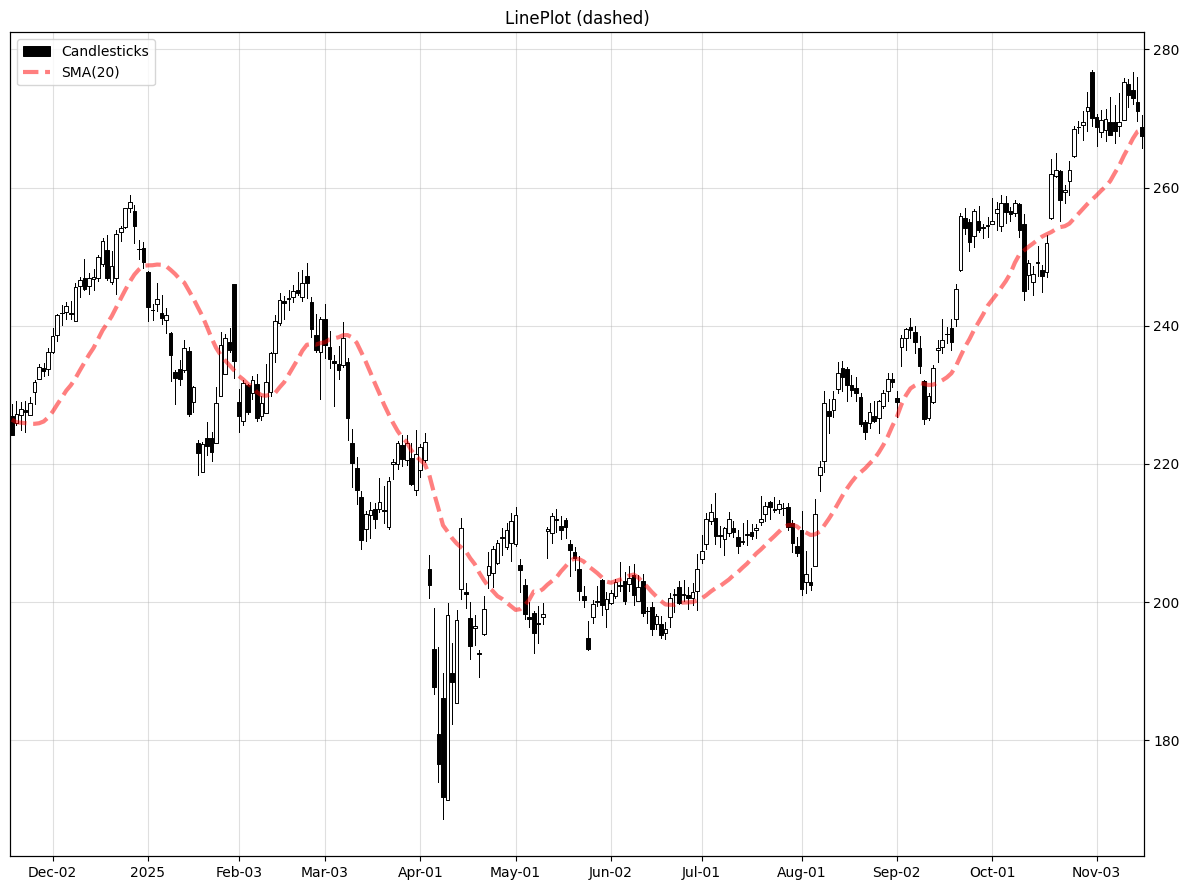

In [25]:
# Dashed line style
Chart(prices, title="LinePlot (dashed)", max_bars=250).plot(
    Candlesticks(),
    LinePlot(SMA(20), style="dashed", color="red", alpha=0.5, width=3),
).show()

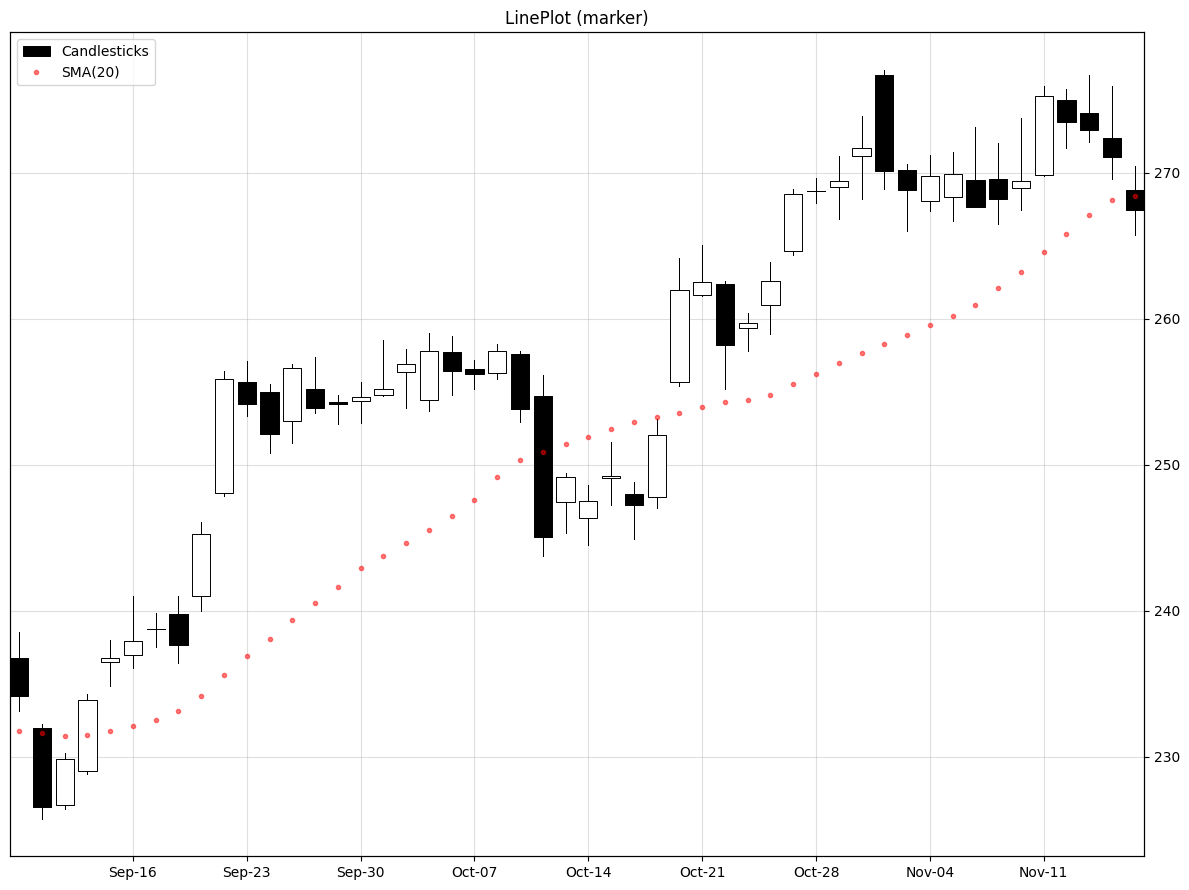

In [26]:
# Marker line style
Chart(prices, title="LinePlot (marker)", max_bars=50).plot(
    Candlesticks(),
    LinePlot(SMA(20), style="marker", color="red", alpha=0.5),
).show()

## Area

Filled area chart. Useful for oscillators displayed as a shaded area.

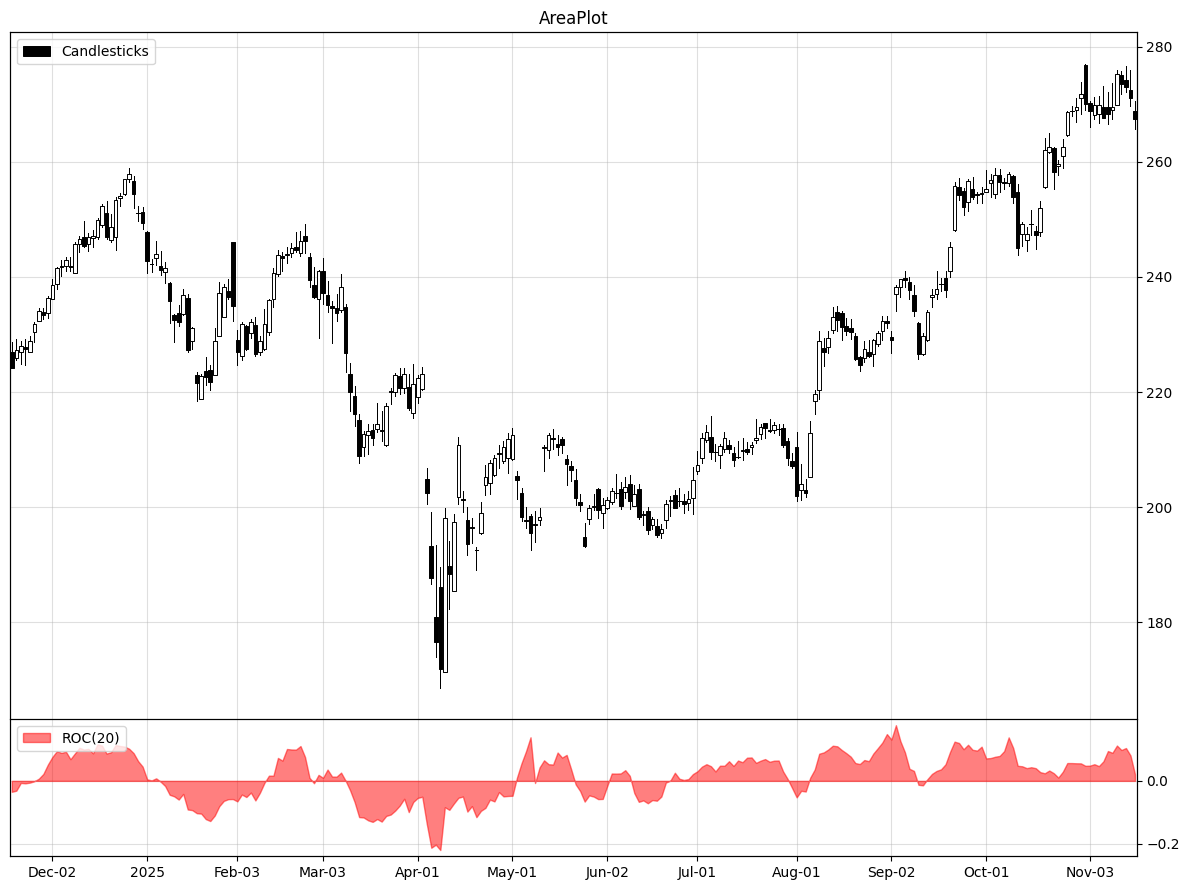

In [27]:
Chart(prices, title="AreaPlot", max_bars=250).plot(
    Candlesticks(),
).pane("below").plot(
    AreaPlot(ROC(20), color="red", alpha=0.5)
).show()

## Bar

Bar chart renderer for indicator values.

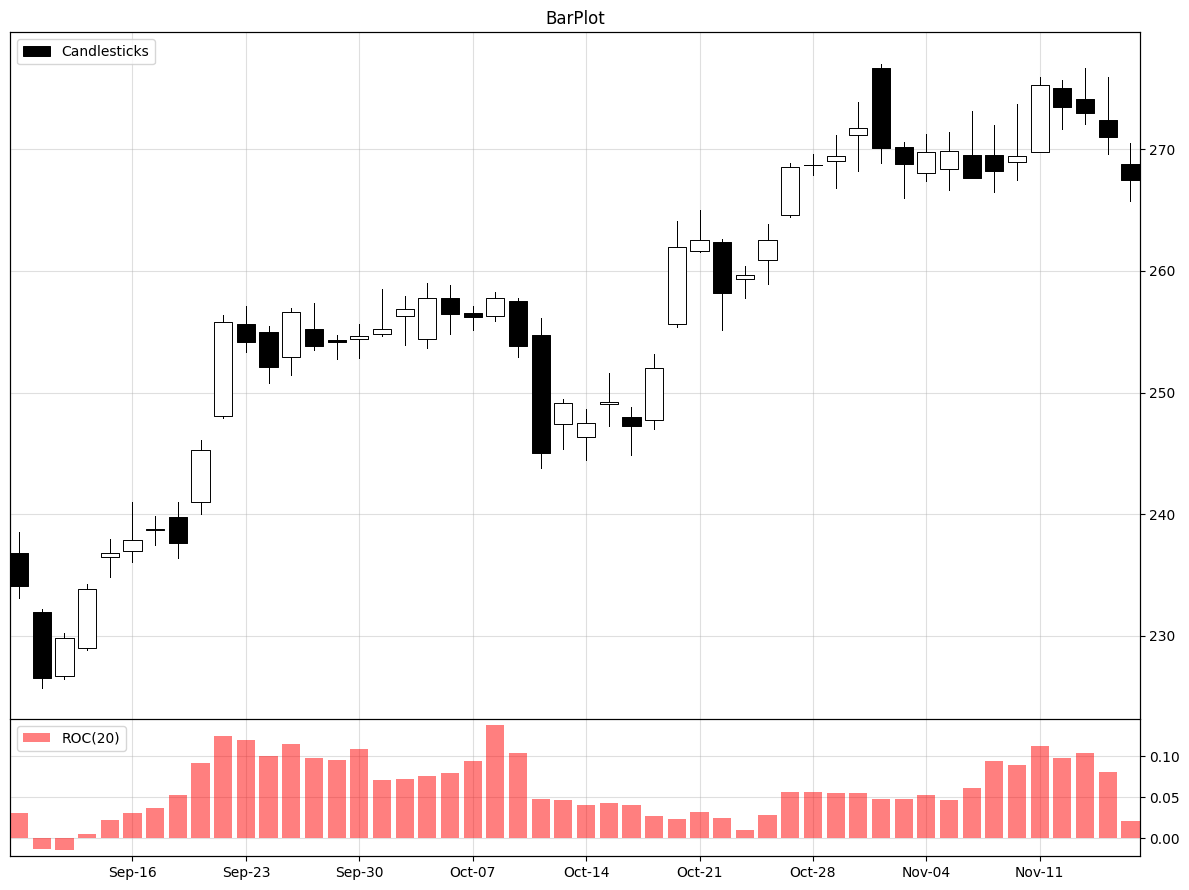

In [28]:
Chart(prices, title="BarPlot", max_bars=50).plot(
    Candlesticks(),
).pane("below").plot(
    BarPlot(ROC(20), color="red", alpha=0.5, width=0.8)
).show()

## Markers

Marks crossings of an indicator above/below zero with small symbols.
By default applied to the last plotted indicator.

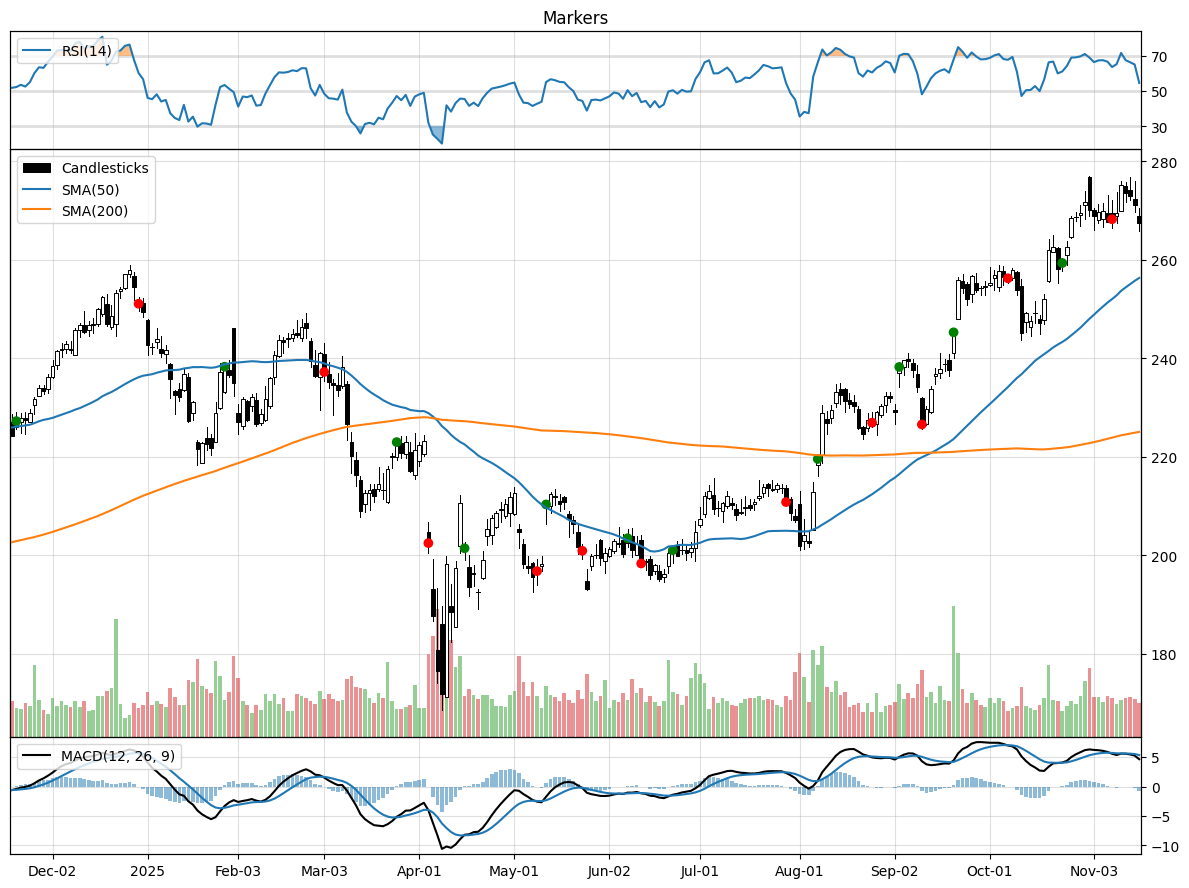

In [29]:
Chart(prices, title="Markers", max_bars=250).plot(
    Candlesticks(), SMA(50), SMA(200), Volume(),
    Pane("above", yticks=(30, 50, 70)),
    LinePlot(RSI(), overbought=70, oversold=30),
    Pane("below"),
    MACD(),
    Markers(MACD().as_expr("macdhist") > 0, color=["red", "green"], alpha=1.0),
).show()

## Stripes

Shades background areas where an indicator value is positive.
By default applied to the last plotted indicator.

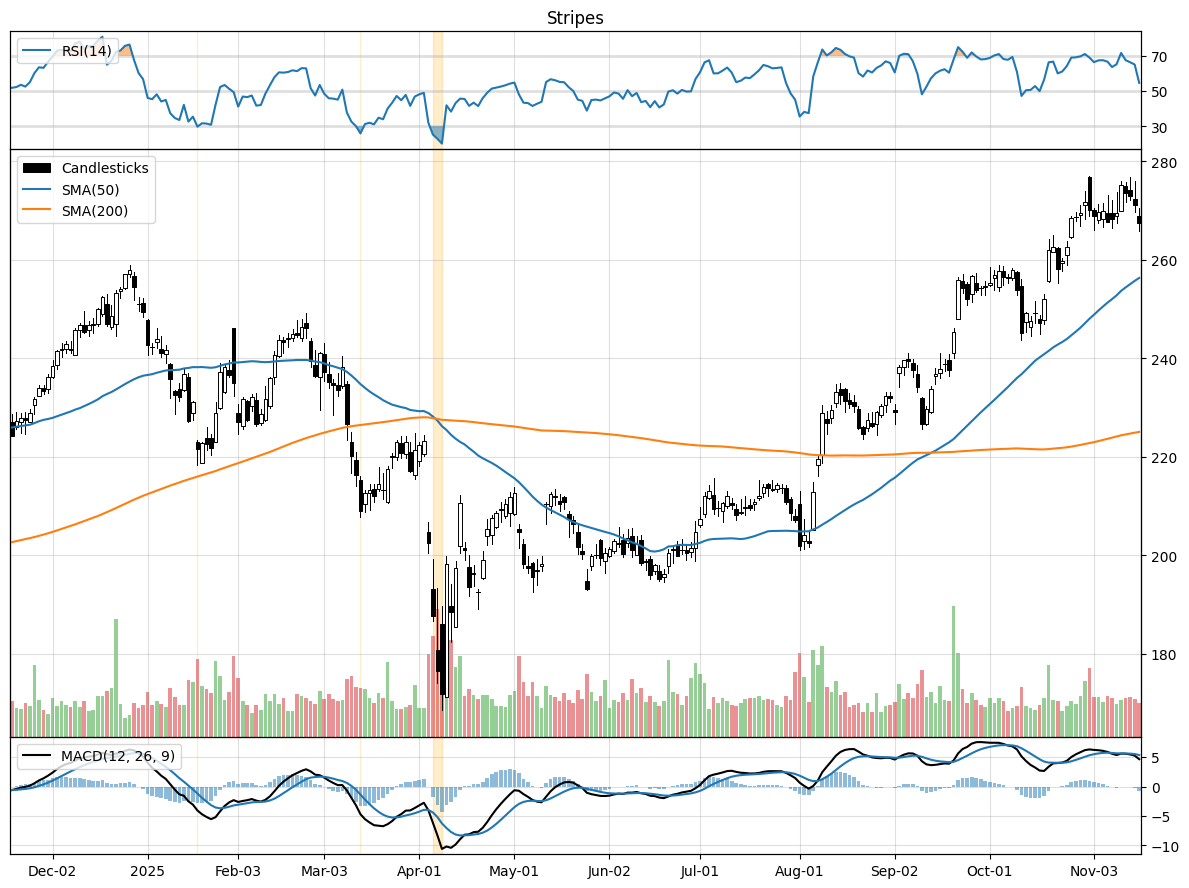

In [30]:
Chart(prices, title="Stripes", max_bars=250).plot(
    Candlesticks(), SMA(50), SMA(200), Volume(),
    Pane("above", yticks=(30, 50, 70)),
    LinePlot(RSI(), overbought=70, oversold=30),
    Pane("below"),
    MACD(),
    Stripes(RSI().as_expr() < 30, color="orange", alpha=0.2),
).show()

## Peaks

Marks local peaks and valleys in an indicator series.

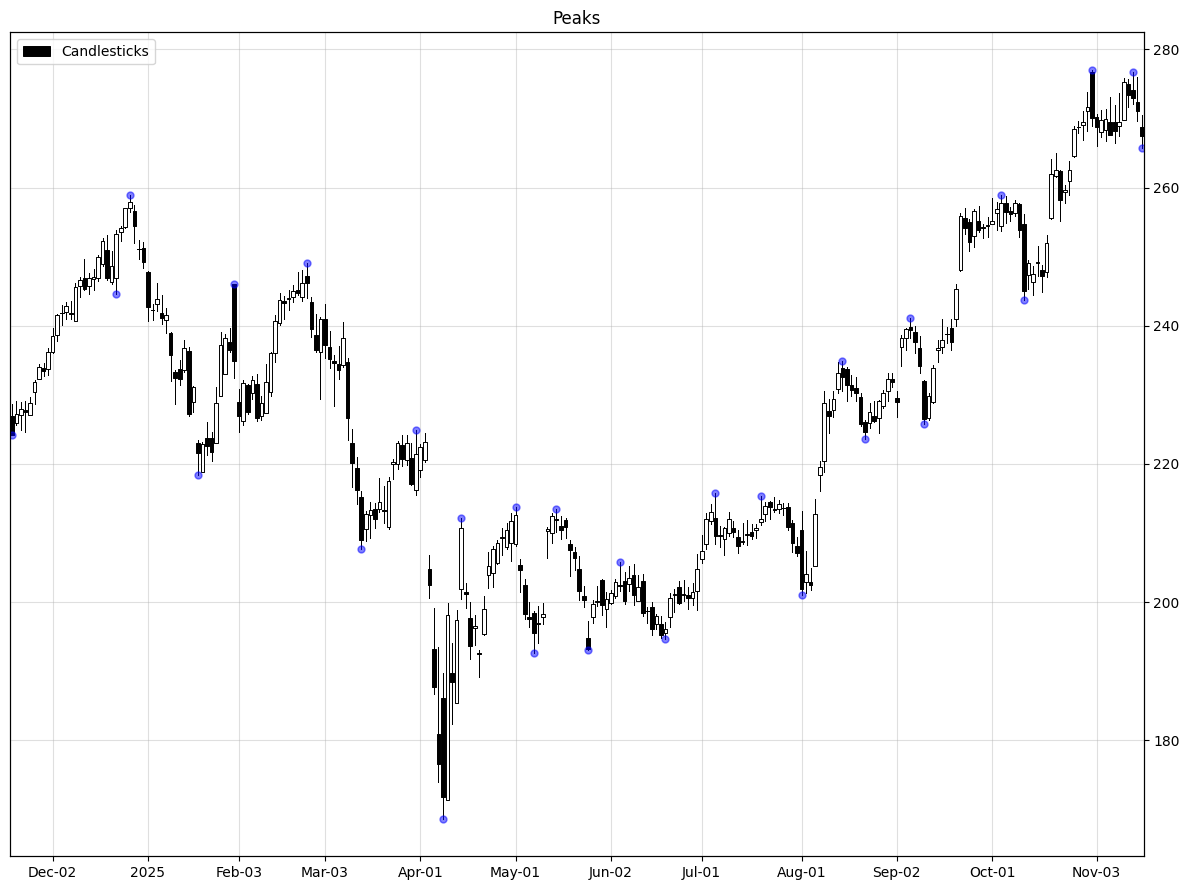

In [31]:
Chart(prices, title="Peaks", max_bars=250).plot(
    Candlesticks(),
    Peaks(5, color='blue')
).show()

## ZigZag

Connects significant swing highs and lows, filtering out minor fluctuations.

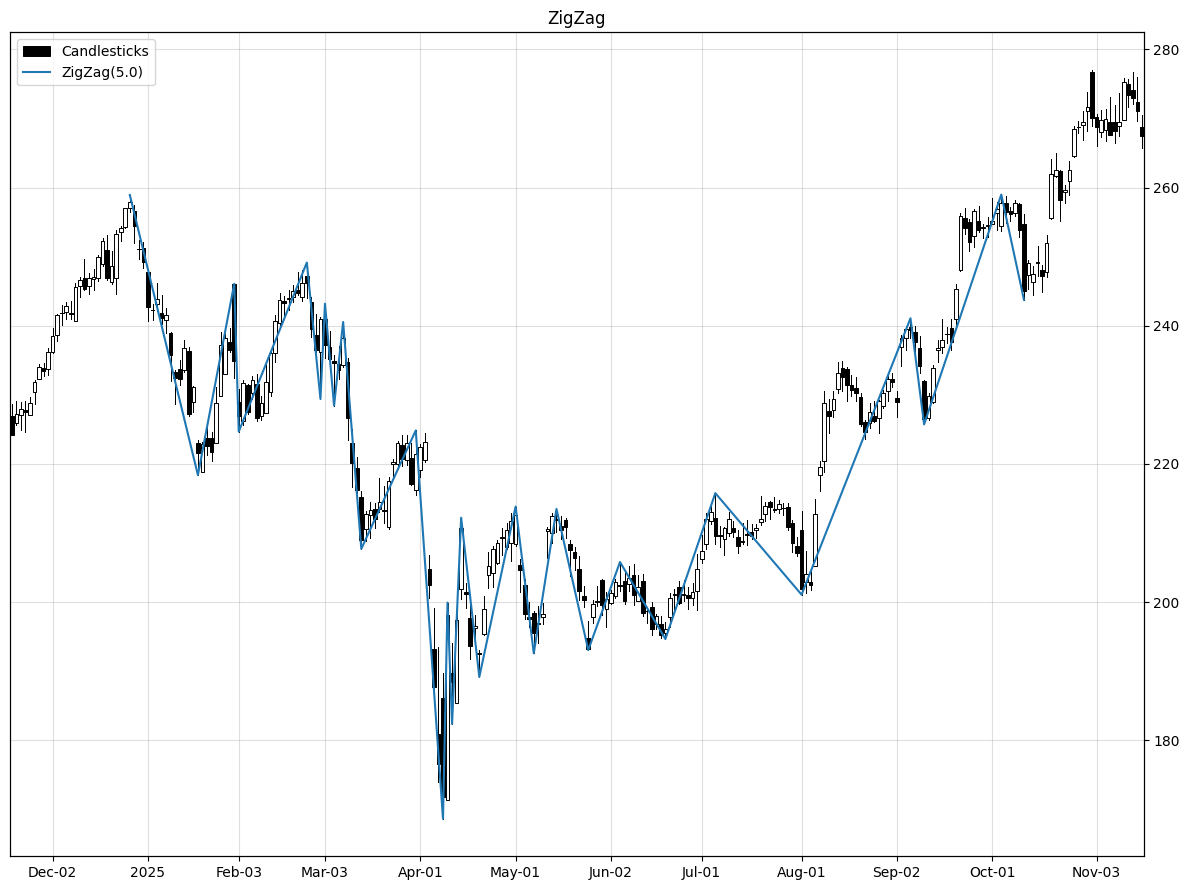

In [32]:
Chart(prices, title="ZigZag", max_bars=250).plot(
    Candlesticks(),
    ZigZag(),
).show()

## Pane

Inline pane control as a primitive. Equivalent to `chart.pane()` but usable inside a flat `plot()` call.
Supports `target`, `height_ratio`, and `yticks`.

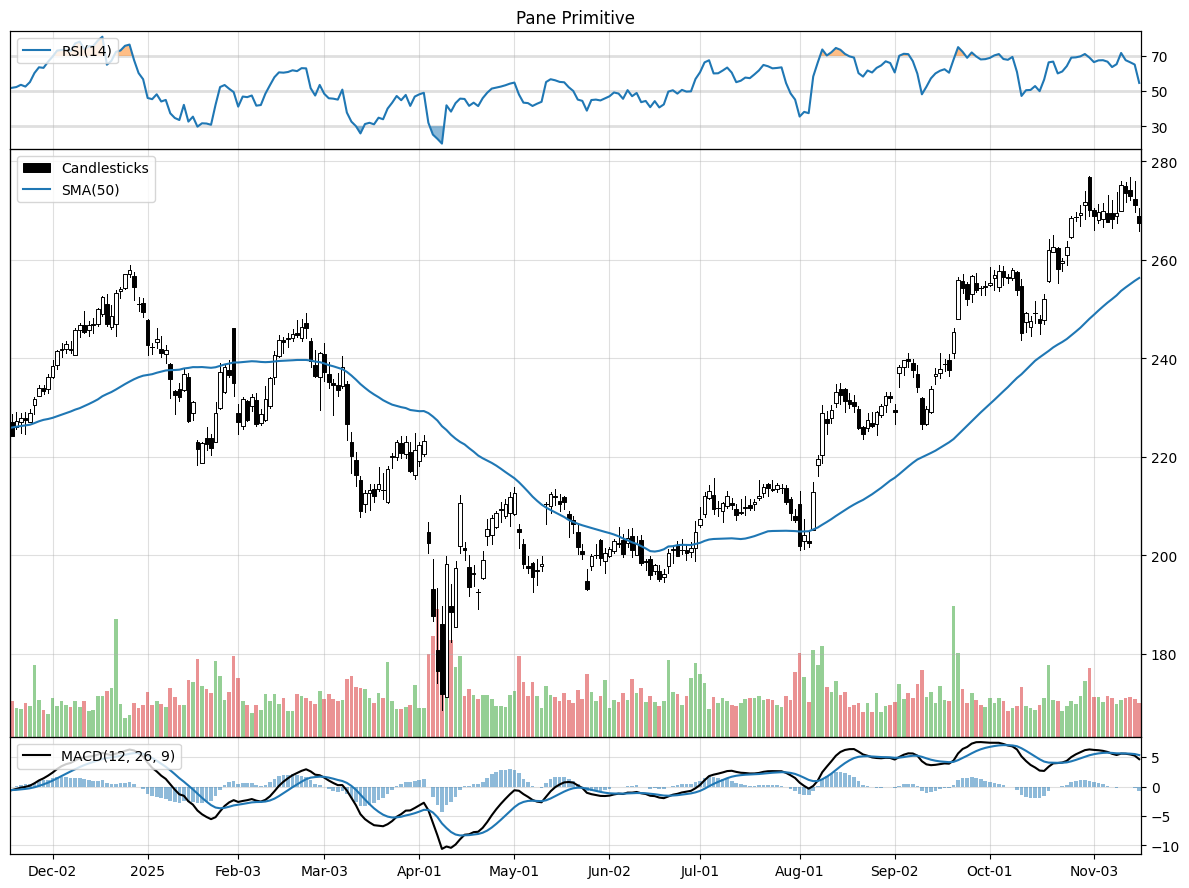

In [33]:
# Pane primitive with RSI overbought/oversold bands
Chart(prices, title="Pane Primitive", max_bars=250).plot(
    Candlesticks(), SMA(50), Volume(),
    Pane("above", yticks=(30, 50, 70)),
    LinePlot(RSI(), overbought=70, oversold=30),
    Pane("below"),
    MACD(),
).show()

## HLine

Horizontal reference line on the current pane. Useful for marking thresholds like ADX trend strength levels.

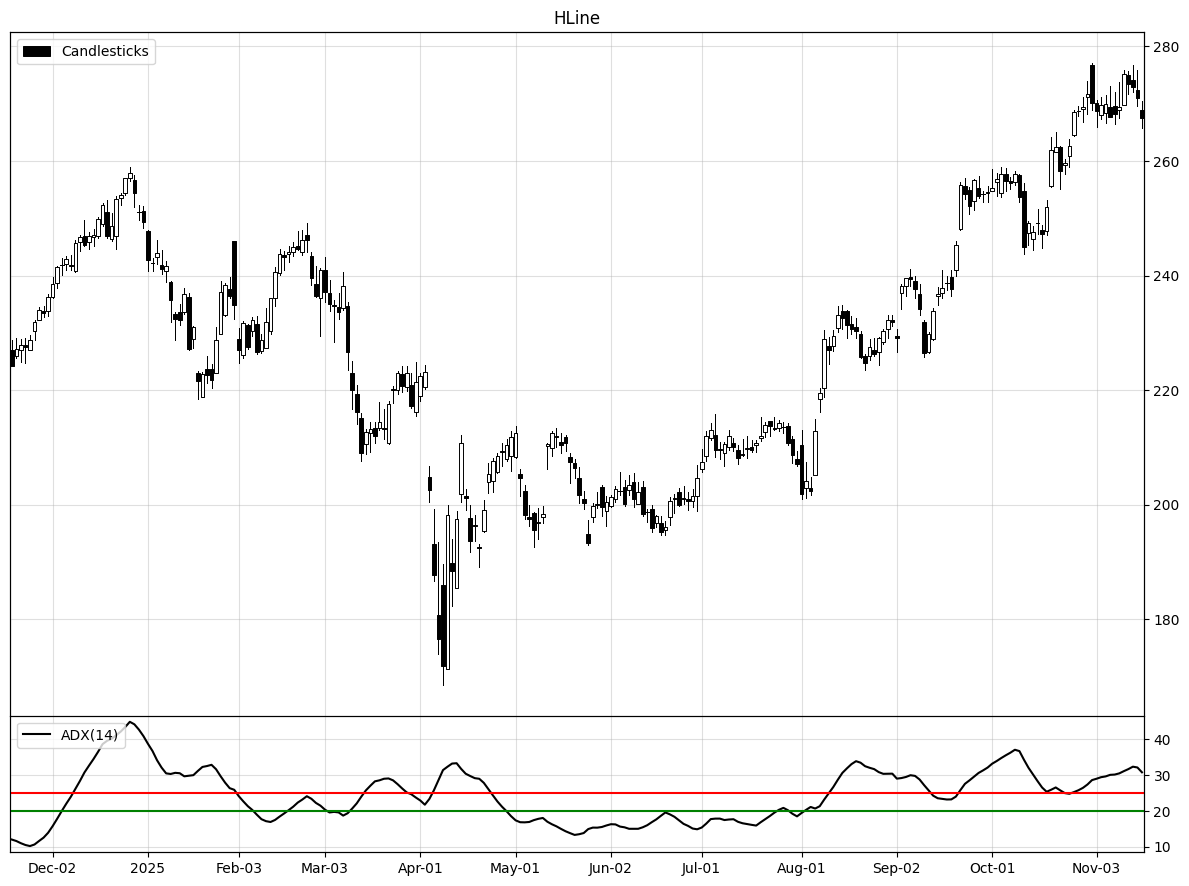

In [34]:
# HLine marking ADX trend thresholds
Chart(prices, title="HLine", max_bars=250).plot(
    Candlesticks(),
    Pane("below"),
    ADX(),
    HLine(20, color="green"),
    HLine(25, color="red"),
).show()